In [1]:
import csv
import numpy as np
import sys
import math
import matplotlib.pyplot as plt

#lattitude and longitude of the Hydrophone
lattitude, longitude = 53.111877242619684, 8.823361523700482

with open('../otter_gps.csv', 'r') as file:
    reader = csv.reader(file)
    gps_data = list(reader)

#inspect data
print(gps_data[0])
print(gps_data[1])
print(reader.line_num)

#remove first line that dosent hold data from csv data 
gps_data = gps_data[1:]

['', 'datetime', 'timestamp (unix epoch) [s]', 'status', 'latitude [deg]', 'longitude [deg]', 'altitude [m]']
['0', '2026-05-13 12:21:15.015349504', '1778674875.0153494', 'sensor_msgs.msg.NavSatStatus(status=0, service=0)', '53.1120163333', '8.826565', '-1.9']
1504


In [2]:
def convertToActualDistance(lat1, lon1, lat2, lon2):
    earthRadius = 6378.137  #in km
    dLat = lat2 * math.pi / 180 - lat1 * math.pi / 180
    dLon = lon2 * math.pi / 180 - lon1 * math.pi / 180
    a = math.sin(dLat/2)**2 + math.cos(lat1 * math.pi / 180) * math.cos(lat2 * math.pi / 180) * math.sin(dLon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    d = earthRadius * c
    return d * 1000 #Meters


In [3]:
# maxValue, minValue, mean
resultsInTime = [0, sys.maxsize, []]
resultsOutTime = [0, sys.maxsize, []]
distance = []
timestamp = []

for row in gps_data:
    time = row[1].split(" ")[1][:8].replace(":", "")
    distanceInMeters = convertToActualDistance(lattitude, longitude, float(row[4]), float(row[5]))
    distance.append(distanceInMeters)
    timestamp.append(time) 
    if int(time) >= 123100:
        if resultsInTime[0] < distanceInMeters:
            resultsInTime[0] = distanceInMeters

        if resultsInTime[1] > distanceInMeters:
            resultsInTime[1] = distanceInMeters

        resultsInTime[2].append(distanceInMeters)

    else:
        if resultsOutTime[0] < distanceInMeters:
            resultsOutTime[0] = distanceInMeters

        if resultsOutTime[1] > distanceInMeters:
            resultsOutTime[1] = distanceInMeters

        resultsOutTime[2].append(distanceInMeters)

inCounter = 0
for val in resultsInTime[2]:
    if val < 10:
        inCounter += 1
outCounter = 0
for val in resultsOutTime[2]:
    if val < 10:
        outCounter += 1 

resultsInTime.append(inCounter)
resultsOutTime.append(outCounter)

resultsInTime[2] = np.mean(resultsInTime[2])
resultsOutTime[2] = np.mean(resultsOutTime[2])

print(timestamp)

timestamp = np.array(timestamp)
timestamp = timestamp.astype(int) + 20000
timestamp =  timestamp.astype(str)
print(resultsInTime, resultsOutTime)

['122115', '122116', '122117', '122118', '122119', '122120', '122121', '122122', '122123', '122124', '122125', '122126', '122127', '122128', '122129', '122130', '122131', '122132', '122133', '122134', '122135', '122136', '122137', '122138', '122139', '122140', '122141', '122142', '122143', '122144', '122145', '122146', '122147', '122148', '122149', '122150', '122151', '122152', '122153', '122154', '122155', '122156', '122157', '122158', '122159', '122200', '122201', '122202', '122203', '122204', '122205', '122206', '122207', '122208', '122209', '122210', '122211', '122212', '122213', '122214', '122215', '122216', '122217', '122218', '122219', '122220', '122221', '122222', '122223', '122224', '122225', '122226', '122227', '122228', '122229', '122230', '122231', '122232', '122233', '122234', '122235', '122236', '122237', '122238', '122239', '122240', '122241', '122242', '122243', '122244', '122245', '122246', '122247', '122248', '122249', '122250', '122251', '122252', '122253', '122254',

In [4]:
print(len(distance))

1503


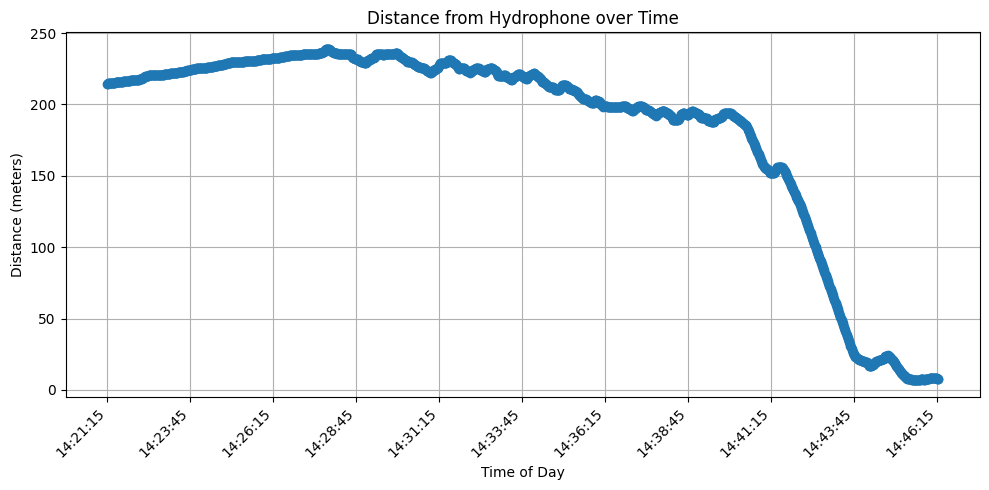

In [5]:
# Plot distance over time
timestamp_labels = [f"{t[:2]}:{t[2:4]}:{t[4:]}" for t in timestamp]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(timestamp_labels, distance, marker='o', linestyle='-')
ax.set_title('Distance from Hydrophone over Time')
ax.set_xlabel('Time of Day')
ax.set_ylabel('Distance (meters)')
ax.grid(True)
# Show only a subset of x-axis labels to keep the chart readable
tick_step = max(1, len(timestamp_labels) // 10)
tick_positions = list(range(0, len(timestamp_labels), tick_step))
ax.set_xticks(tick_positions)
ax.set_xticklabels([timestamp_labels[i] for i in tick_positions], rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [6]:
# Convert data into GPX format and save to file
import xml.etree.ElementTree as ET
from datetime import datetime

def save_gps_data_as_gpx(gps_rows, output_path):
    gpx = ET.Element(
        'gpx',
        version='1.1',
        creator='gps_data_match',
        xmlns='http://www.topografix.com/GPX/1/1'
    )
    trk = ET.SubElement(gpx, 'trk')
    ET.SubElement(trk, 'name').text = 'otter_gps_track'
    trkseg = ET.SubElement(trk, 'trkseg')

    for row in gps_rows:
        lat = float(row[4])
        lon = float(row[5])
        ele = float(row[6]) if row[6] else None
        time_str = row[1]

        try:
            timestamp = datetime.fromisoformat(time_str)
        except ValueError:
            timestamp = datetime.strptime(time_str, '%Y-%m-%d %H:%M:%S.%f')

        trkpt = ET.SubElement(trkseg, 'trkpt', lat=str(lat), lon=str(lon))
        if ele is not None:
            ET.SubElement(trkpt, 'ele').text = str(ele)
        ET.SubElement(trkpt, 'time').text = timestamp.strftime('%Y-%m-%dT%H:%M:%S.%f')[:-3] + 'Z'

    tree = ET.ElementTree(gpx)
    tree.write(output_path, encoding='utf-8', xml_declaration=True)
    print(f'Saved {len(gps_rows)} waypoints to {output_path}')

save_gps_data_as_gpx(gps_data, 'otter_gps.gpx')

Saved 1503 waypoints to otter_gps.gpx
